# DINOv2 Feature Visualization - Driving Footage (Autumn Leaves)

## Setup

In [ ]:
import subprocess, os, sys

UV = '/root/.local/bin/uv'

subprocess.run([
    UV, 'pip', 'install', '--system',
    'torch', 'torchvision',
    'opencv-python-headless',
    'matplotlib',
    'numpy',
    'Pillow',
    'tqdm',
    'scikit-learn',
    'requests',
], check=True)

In [2]:
import time, os

VIDEO_PATH = './driving_autumn.mp4'
VIDEO_URL  = 'https://www.dropbox.com/scl/fi/a801ji83at23txlql4s8j/leaves.mp4?rlkey=bte7qa7a98ckio4d82e5o3415&st=6vmfeyu4&dl=1'
RUN_DIR    = f'./runs/p77/{int(time.time())}'
FRAMES_DIR = f'{RUN_DIR}/frames'
OUTPUT_DIR = f'{RUN_DIR}/output'

In [3]:
import subprocess, os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from tqdm import tqdm
from sklearn.decomposition import PCA
from torchvision import transforms

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

objc[50475]: Class AVFFrameReceiver is implemented in both /Users/pranav/.venv/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1113943a8) and /Users/pranav/.venv/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x124e1c3a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[50475]: Class AVFAudioReceiver is implemented in both /Users/pranav/.venv/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1113943f8) and /Users/pranav/.venv/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x124e1c3f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


Using device: mps


## 1. Download & Extract Frames

In [4]:
import requests

os.makedirs(FRAMES_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(VIDEO_PATH):
    print('Downloading video...')
    r = requests.get(VIDEO_URL, stream=True)
    r.raise_for_status()
    with open(VIDEO_PATH, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print('Done.')
else:
    print('Already downloaded.')

IMG_SIZE = 518

def center_crop_resize(frame_bgr, size=IMG_SIZE):
    img = Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    w, h = img.size
    s = min(w, h)
    img = img.crop(((w - s) // 2, (h - s) // 2, (w + s) // 2, (h + s) // 2))
    return img.resize((size, size), Image.LANCZOS)

cap = cv2.VideoCapture(VIDEO_PATH)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps   = cap.get(cv2.CAP_PROP_FPS)
frame_paths = []
saved = 0
max_frames = int(fps * 10)
print(f'{total} frames @ {fps:.1f} fps  →  saving first {max_frames} (10s)')
while True:
    ret, frame = cap.read()
    if not ret or saved >= max_frames:
        break
    img = center_crop_resize(frame)
    path = f'{FRAMES_DIR}/{saved:04d}.png'
    img.save(path)
    frame_paths.append(path)
    saved += 1
cap.release()
print(f'Saved {saved} frames to {RUN_DIR}')

Already downloaded.


/Users/pranav/.venv/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


3600 frames @ 60.0 fps  →  saving first 600 (10s)
Saved 600 frames to ./runs/p77/1776554989


## 2. Load DINOv2

In [5]:
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
model = model.to(DEVICE).eval()

PATCH_SIZE = 14
N_PATCHES  = IMG_SIZE // PATCH_SIZE  # 32
print(f'Patch grid: {N_PATCHES}x{N_PATCHES}')

preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

def get_features(img_path):
    img = Image.open(img_path).convert('RGB')
    x = preprocess(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model.forward_features(x)
    return out['x_norm_patchtokens'].squeeze(0)  # (N, D)

Using cache found in /Users/pranav/.cache/torch/hub/facebookresearch_dinov2_main
/Users/pranav/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/pranav/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/pranav/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Patch grid: 37x37


## 3. Feature Similarity (query point -> heatmap)

Query patch (28, 18), flat index 1054


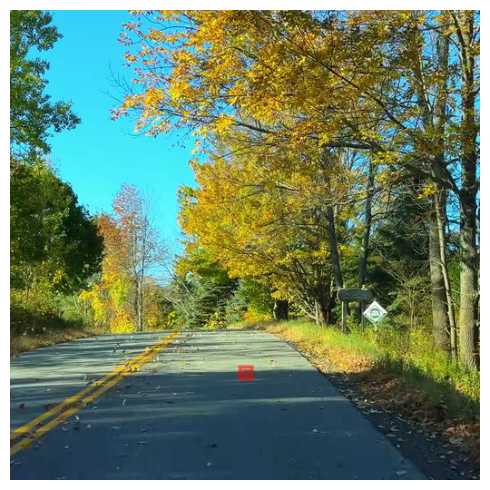

In [6]:
# Pick a leaf/foliage patch in frame 0 as the query
QUERY_X = 259
QUERY_Y = 400
QUERY_FRAME_IDX = 0

qr = QUERY_Y // PATCH_SIZE
qc = QUERY_X // PATCH_SIZE
q_idx = qr * N_PATCHES + qc
print(f'Query patch ({qr}, {qc}), flat index {q_idx}')

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(Image.open(frame_paths[QUERY_FRAME_IDX]))
ax.add_patch(plt.Rectangle((qc*PATCH_SIZE, qr*PATCH_SIZE), PATCH_SIZE, PATCH_SIZE,
                             linewidth=2, edgecolor='red', facecolor='red', alpha=0.4))
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/query_location.png', dpi=150)
plt.show()

In [7]:
q_feats = get_features(frame_paths[QUERY_FRAME_IDX])
q_vec   = F.normalize(q_feats[q_idx].unsqueeze(0), dim=-1)

SIM_DIR = f'{OUTPUT_DIR}/similarity'
os.makedirs(SIM_DIR, exist_ok=True)

for fi, fpath in enumerate(tqdm(frame_paths)):
    feats    = F.normalize(get_features(fpath), dim=-1)
    sim      = (feats @ q_vec.T).squeeze(-1).cpu().numpy()
    sim_low  = sim.reshape(N_PATCHES, N_PATCHES).astype(np.float32)
    sim_up   = cv2.resize(sim_low, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    sim_norm = (sim_up - sim_up.min()) / (sim_up.max() - sim_up.min() + 1e-8)
    frame_np = np.array(Image.open(fpath))
    heat     = (cm.inferno(sim_norm)[:, :, :3] * 255).astype(np.uint8)
    frame_marked = frame_np.copy()
    if fi == 0:
        cv2.rectangle(frame_marked, (qc*PATCH_SIZE, qr*PATCH_SIZE),
                      ((qc+1)*PATCH_SIZE, (qr+1)*PATCH_SIZE), (255,0,0), 2)
    side_by_side = np.concatenate([frame_marked, heat], axis=1)
    Image.fromarray(side_by_side).save(f'{SIM_DIR}/{fi:04d}.png')

subprocess.run([
    'ffmpeg', '-y', '-framerate', str(fps),
    '-i', f'{SIM_DIR}/%04d.png',
    '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
    f'{OUTPUT_DIR}/similarity.mp4'
], check=True)
print('Done: similarity.mp4')

100%|██████████| 600/600 [05:31<00:00,  1.81it/s]
ffmpeg version 8.1 Copyright (c) 2000-2026 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.6.4.2)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
  libavutil      60. 26.100 / 60. 26.100
  libavcodec     62. 28.100 / 62. 28.100
  libavformat    62. 12.100 / 62. 12.100
  libavdevice    62.  3.100 / 62.  3.100
  libavfilter    11. 14.100 / 11. 14.100
  libswscale      9.  5.100 /  9.  5.100
  libswresample   6.  3.100 /  6.  3.100
Input #0, image2, from './runs/p77/1776554989/output/similarity/%04d.png':
  Duration: 00:00:10.00, start: 0.000000, bitrate: N/A
  Stream #0:0: Video: png, rg

Done: similarity.mp4


[out#0/mp4 @ 0xafcc28240] video:10037KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.079562%
frame=  600 fps= 27 q=-1.0 Lsize=   10045KiB time=00:00:09.96 bitrate=8256.1kbits/s speed=0.442x elapsed=0:00:22.53    
[libx264 @ 0xafd018a80] frame I:3     Avg QP:26.42  size: 79318
[libx264 @ 0xafd018a80] frame P:151   Avg QP:28.58  size: 37918
[libx264 @ 0xafd018a80] frame B:446   Avg QP:30.56  size:  9671
[libx264 @ 0xafd018a80] consecutive B-frames:  0.8%  0.0%  0.5% 98.7%
[libx264 @ 0xafd018a80] mb I  I16..4: 11.9% 65.4% 22.7%
[libx264 @ 0xafd018a80] mb P  I16..4:  6.2% 12.2%  2.3%  P16..4: 34.0% 24.7% 15.6%  0.0%  0.0%    skip: 5.0%
[libx264 @ 0xafd018a80] mb B  I16..4:  1.8%  2.6%  0.2%  B16..8: 43.0% 14.6%  3.9%  direct: 3.7%  skip:30.3%  L0:40.0% L1:41.7% BI:18.3%
[libx264 @ 0xafd018a80] 8x8 transform intra:58.2% inter:69.1%
[libx264 @ 0xafd018a80] coded y,uvDC,uvAC intra: 41.3% 78.4% 38.2% inter: 24.4% 21.6% 2.5%
[libx264 @ 0xafd018a80] i16 v,h

## 4. PCA Visualization

In [8]:
all_feats = np.concatenate([
    get_features(fpath).cpu().numpy()
    for fpath in tqdm(frame_paths[::3][:60], desc='Collecting features')
], axis=0)
print(f'Feature matrix: {all_feats.shape}')

pca = PCA(n_components=3)
pca.fit(all_feats)
print(f'Explained variance: {pca.explained_variance_ratio_}')

Feature matrix: (82140, 768)
Explained variance: [0.14148375 0.09947165 0.07523642]


In [9]:
PCA_DIR = f'{OUTPUT_DIR}/pca'
os.makedirs(PCA_DIR, exist_ok=True)

for fi, fpath in enumerate(tqdm(frame_paths, desc='PCA frames')):
    feats = get_features(fpath).cpu().numpy()
    proj  = pca.transform(feats)
    proj  = (proj - proj.min(0)) / (proj.max(0) - proj.min(0) + 1e-8)
    pca_low = proj.reshape(N_PATCHES, N_PATCHES, 3).astype(np.float32)
    pca_up  = cv2.resize(pca_low, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    pca_img = (np.clip(pca_up, 0, 1) * 255).astype(np.uint8)
    frame_np = np.array(Image.open(fpath))
    Image.fromarray(np.concatenate([frame_np, pca_img], axis=1)).save(f'{PCA_DIR}/{fi:04d}.png')

subprocess.run([
    'ffmpeg', '-y', '-framerate', str(fps),
    '-i', f'{PCA_DIR}/%04d.png',
    '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
    f'{OUTPUT_DIR}/pca.mp4'
], check=True)
print('Done: pca.mp4')

PCA frames: 100%|██████████| 600/600 [05:35<00:00,  1.79it/s]
ffmpeg version 8.1 Copyright (c) 2000-2026 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.6.4.2)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
  libavutil      60. 26.100 / 60. 26.100
  libavcodec     62. 28.100 / 62. 28.100
  libavformat    62. 12.100 / 62. 12.100
  libavdevice    62.  3.100 / 62.  3.100
  libavfilter    11. 14.100 / 11. 14.100
  libswscale      9.  5.100 /  9.  5.100
  libswresample   6.  3.100 /  6.  3.100
Input #0, image2, from './runs/p77/1776554989/output/pca/%04d.png':
  Duration: 00:00:10.00, start: 0.000000, bitrate: N/A
  Stream #0:0: Video: pn

Done: pca.mp4


[out#0/mp4 @ 0x94cc20240] video:10218KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.078191%
frame=  600 fps= 22 q=-1.0 Lsize=   10226KiB time=00:00:09.96 bitrate=8404.8kbits/s speed=0.37x elapsed=0:00:26.96    
[libx264 @ 0x94cc1ca80] frame I:3     Avg QP:26.56  size: 79031
[libx264 @ 0x94cc1ca80] frame P:151   Avg QP:28.67  size: 38628
[libx264 @ 0x94cc1ca80] frame B:446   Avg QP:30.68  size:  9848
[libx264 @ 0x94cc1ca80] consecutive B-frames:  0.8%  0.0%  0.5% 98.7%
[libx264 @ 0x94cc1ca80] mb I  I16..4: 13.6% 63.7% 22.6%
[libx264 @ 0x94cc1ca80] mb P  I16..4: 10.1% 19.1%  2.4%  P16..4: 31.6% 19.5% 13.5%  0.0%  0.0%    skip: 3.8%
[libx264 @ 0x94cc1ca80] mb B  I16..4:  2.2%  3.9%  0.2%  B16..8: 37.6% 10.8%  3.6%  direct:11.0%  skip:30.7%  L0:37.6% L1:41.7% BI:20.7%
[libx264 @ 0x94cc1ca80] 8x8 transform intra:60.9% inter:66.7%
[libx264 @ 0x94cc1ca80] coded y,uvDC,uvAC intra: 38.1% 88.4% 52.0% inter: 24.8% 36.8% 3.7%
[libx264 @ 0x94cc1ca80] i16 v,h,

## 5. Preview

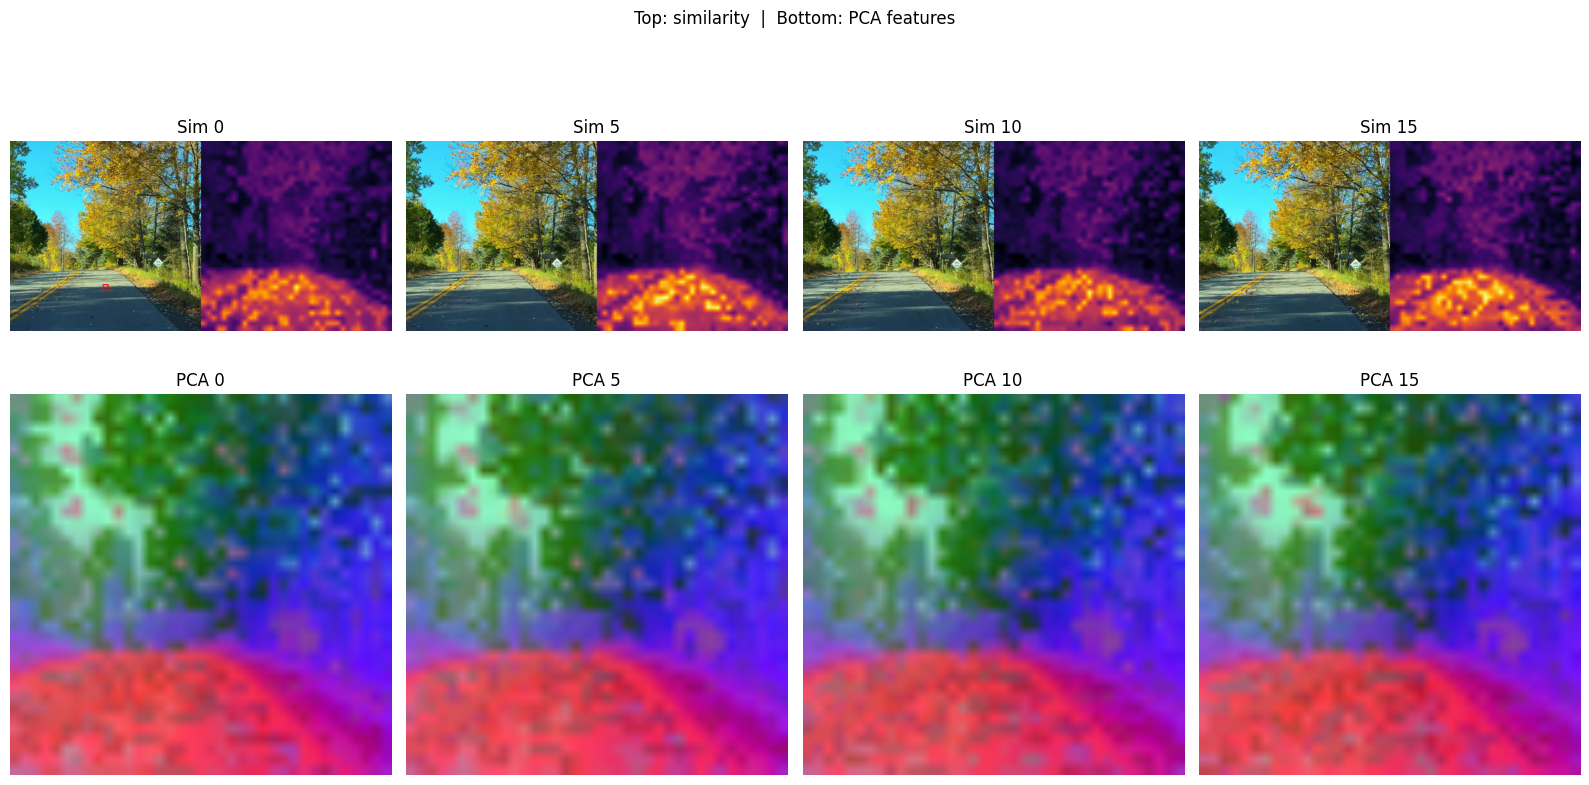

In [10]:
idxs = [0, 5, 10, 15]
fig, axes = plt.subplots(2, len(idxs), figsize=(4*len(idxs), 8))

for col, i in enumerate(idxs):
    sim_f = Image.open(f'{SIM_DIR}/{i:04d}.png')
    pca_f = Image.open(f'{PCA_DIR}/{i:04d}.png')
    w = pca_f.width // 2
    axes[0, col].imshow(sim_f); axes[0, col].axis('off'); axes[0, col].set_title(f'Sim {i}')
    axes[1, col].imshow(pca_f.crop((w, 0, pca_f.width, pca_f.height)))
    axes[1, col].axis('off'); axes[1, col].set_title(f'PCA {i}')

plt.suptitle('Top: similarity  |  Bottom: PCA features')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/preview.png', dpi=150)
plt.show()